In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [2]:
df_categorical_imputed = pd.read_csv("categorical_imputed_per_location.csv", parse_dates=['Date'])

In [3]:
df_categorical_imputed.isnull().sum().sum()

0

In [4]:
#dropped rain tomorrow. Because in reality, this would'nt be known
df_categorical_imputed.drop('RainTomorrow', inplace = True, axis=1)

In [5]:
# Sort by Location and Date
df = df_categorical_imputed.sort_values(['Location', 'Date']).reset_index(drop=True)

In [6]:
df.dtypes

MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
Evaporation             float64
Sunshine                float64
WindGustSpeed           float64
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Cloud9am                float64
Cloud3pm                float64
Temp9am                 float64
Temp3pm                 float64
WindGustDir              object
WindDir9am               object
WindDir3pm               object
RainToday                object
Date             datetime64[ns]
Location                 object
dtype: object

In [7]:
df = df.copy()

In [8]:
df.loc[:, 'Month'] = df['Date'].dt.strftime('%B')

In [9]:
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Date,Location,Month
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,W,W,WNW,No,2008-12-01,Albury,December
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,WNW,NNW,WSW,No,2008-12-02,Albury,December
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,WSW,W,WSW,No,2008-12-03,Albury,December
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,NE,SE,E,No,2008-12-04,Albury,December
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,W,ENE,NW,No,2008-12-05,Albury,December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117961,5.800000,19.900000,0.000000,2.000000,6.440000,22.000000,11.000000,9.000000,52.000000,22.000000,...,1.800000,11.100000,19.100000,ENE,ESE,ESE,No,2017-06-21,Woomera,June
117962,7.800000,19.000000,0.000000,1.400000,4.760000,31.000000,13.000000,17.000000,48.000000,37.000000,...,6.000000,11.100000,18.000000,NNE,ENE,NNW,No,2017-06-22,Woomera,June
117963,8.000000,22.500000,0.000000,4.000000,6.820000,33.000000,13.000000,15.000000,57.000000,31.000000,...,3.000000,11.500000,21.500000,NNW,N,NW,No,2017-06-23,Woomera,June
117964,11.500000,20.900000,0.000000,4.000000,7.900000,33.000000,9.000000,20.000000,61.000000,35.000000,...,5.200000,12.500000,20.700000,W,WSW,WSW,No,2017-06-24,Woomera,June


In [10]:
# Encode categorical variables using Ordinal Encoding (for embedding later)

categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']
ordinal_encoders = {}

for col in categorical_cols:
    oe = OrdinalEncoder(dtype='int64')
    df[col] = oe.fit_transform(df[[col]])
    ordinal_encoders[col] = oe  # Save for inverse transform later if needed


In [11]:
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Date,Location,Month
0,13.400000,22.900000,0.600000,6.828235,8.666250,44.000000,20.000000,24.000000,71.000000,22.000000,...,4.789474,16.900000,21.800000,13,13,14,0,2008-12-01,0,2
1,7.400000,32.600000,0.000000,5.794592,9.464265,59.000000,4.000000,22.000000,44.000000,25.000000,...,2.489113,17.200000,24.300000,14,6,15,0,2008-12-02,0,2
2,12.900000,25.700000,0.000000,5.760000,9.140000,46.000000,19.000000,26.000000,38.000000,30.000000,...,4.000000,21.000000,23.200000,15,13,15,0,2008-12-03,0,2
3,9.200000,28.000000,0.000000,5.984526,6.553699,43.628141,11.000000,9.000000,45.000000,16.000000,...,4.366356,18.100000,26.500000,4,9,0,0,2008-12-04,0,2
4,15.154894,25.785654,1.936709,6.828235,8.666250,43.726775,14.515152,21.195745,61.722944,47.689362,...,4.801102,20.180519,24.071064,13,1,7,0,2008-12-05,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117961,5.800000,19.900000,0.000000,2.000000,6.440000,22.000000,11.000000,9.000000,52.000000,22.000000,...,1.800000,11.100000,19.100000,1,2,2,0,2017-06-21,38,6
117962,7.800000,19.000000,0.000000,1.400000,4.760000,31.000000,13.000000,17.000000,48.000000,37.000000,...,6.000000,11.100000,18.000000,5,1,6,0,2017-06-22,38,6
117963,8.000000,22.500000,0.000000,4.000000,6.820000,33.000000,13.000000,15.000000,57.000000,31.000000,...,3.000000,11.500000,21.500000,6,3,7,0,2017-06-23,38,6
117964,11.500000,20.900000,0.000000,4.000000,7.900000,33.000000,9.000000,20.000000,61.000000,35.000000,...,5.200000,12.500000,20.700000,13,15,15,0,2017-06-24,38,6


In [12]:
df.to_csv("categorical imputed - ordinal encoded.csv", index=False)

In [2]:
df = pd.read_csv("categorical imputed - ordinal encoded.csv", parse_dates=['Date'])

In [4]:
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']

In [5]:
print(df[categorical_cols].isnull().sum())

Location       0
WindGustDir    0
WindDir9am     0
WindDir3pm     0
RainToday      0
Month          0
dtype: int64


In [6]:
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Location', 'Month']:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, nunique={df[col].nunique()}")

WindGustDir: min=0, max=15, nunique=16
WindDir9am: min=0, max=15, nunique=16
WindDir3pm: min=0, max=15, nunique=16
RainToday: min=0, max=1, nunique=2
Location: min=0, max=38, nunique=39
Month: min=0, max=11, nunique=12


In [7]:
df.dtypes

MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
Evaporation             float64
Sunshine                float64
WindGustSpeed           float64
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Cloud9am                float64
Cloud3pm                float64
Temp9am                 float64
Temp3pm                 float64
WindGustDir               int64
WindDir9am                int64
WindDir3pm                int64
RainToday                 int64
Date             datetime64[ns]
Location                  int64
Month                     int64
dtype: object

In [8]:
# Normalize numerical features using StandardScaler

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
numeric_cols.remove('Rainfall')  # This is our target, we handle it separately

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [16]:
'''def create_lstm_sequences_split(
    df,
    cat_static=['Location', 'Month'],
    cat_sequence=['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'],
    target_col='Rainfall',
    time_col='Date',
    location_col='Location',
    n_steps=7
):
    X_num, X_cat_static, X_cat_seq, y = [], [], [], []

    # Group by location to keep sequences localized
    for loc, group in df.groupby(location_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        for i in range(len(group) - n_steps):
            window = group.iloc[i:i + n_steps]

            # Target is Rainfall at t+1
            y.append(group.iloc[i + n_steps][target_col])

            # Static categorical: use value at t=0
            static_cat = window.iloc[0][cat_static].values
            X_cat_static.append(static_cat)

            # Time-varying categorical features (entire sequence)
            seq_cat = window[cat_sequence].values
            X_cat_seq.append(seq_cat)

            # Numerical features: remove static and categorical ones
            drop_cols = [time_col, target_col] + cat_static + cat_sequence
            seq_num = window.drop(columns=drop_cols).values
            X_num.append(seq_num)

    return (
        np.array(X_num),         # shape: (samples, timesteps, num_numerical_features)
        np.array(X_cat_static),  # shape: (samples, num_static_cats)
        np.array(X_cat_seq),     # shape: (samples, timesteps, num_cat_seq_features)
        np.array(y)              # shape: (samples,)
    )

# Run it
X_num, X_cat_static, X_cat_seq, y = create_lstm_sequences_split(df)
'''

In [16]:
def create_lstm_sequences_split(
    df,
    cat_static=['Location', 'Month'],
    cat_sequence=['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'],
    target_col='Rainfall',
    time_col='Date',
    location_col='Location',
    n_steps=7,
    forecast_horizon=1  # Change this to 5, 10, etc.
):
    X_num, X_cat_static, X_cat_seq, y = [], [], [], []

    for loc, group in df.groupby(location_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        for i in range(len(group) - n_steps - forecast_horizon + 1):
            window = group.iloc[i:i + n_steps]

            # Target is Rainfall at t + forecast_horizon
            y.append(group.iloc[i + n_steps + forecast_horizon - 1][target_col])

            static_cat = window.iloc[0][cat_static].values
            X_cat_static.append(static_cat)

            seq_cat = window[cat_sequence].values
            X_cat_seq.append(seq_cat)

            drop_cols = [time_col, target_col] + cat_static + cat_sequence
            seq_num = window.drop(columns=drop_cols).values
            X_num.append(seq_num)

    return (
        np.array(X_num),
        np.array(X_cat_static),
        np.array(X_cat_seq),
        np.array(y)
    )

X_num, X_cat_static, X_cat_seq, y = create_lstm_sequences_split(df)

In [55]:
print("X_num shape:", X_num.shape)           # (samples, 7, num_numerical_features)
print("X_cat_static shape:", X_cat_static.shape)  # (samples, 2)
print("X_cat_seq shape:", X_cat_seq.shape)   # (samples, 7, 4)
print("y shape:", y.shape)                   # (samples,)


X_num shape: (117342, 7, 15)
X_cat_static shape: (117342, 2)
X_cat_seq shape: (117342, 7, 4)
y shape: (117342,)


In [56]:
print("Sample numerical sequence:\n", X_num[0])
print("Sample static categorical:\n", X_cat_static[0])
print("Sample sequence categorical:\n", X_cat_seq[0])
print("Sample target (Rainfall at t+1):", y[0])


Sample numerical sequence:
 [[ 0.19552115 -0.03090174  0.32884005  0.24414907  0.27490265  0.66575804
   0.60132348  0.08107555 -1.42173178 -1.42534581 -1.18547526  1.51983447
   0.25730817  0.02200286  0.01426966]
 [-0.72516364  1.32317824  0.05305806  0.49321124  1.36788324 -1.11806207
   0.3769555  -1.34892713 -1.27684326 -1.00626634 -0.99406809 -0.03577307
  -0.72010137  0.06748937  0.3698355 ]
 [ 0.11879742  0.35996671  0.04382869  0.39200742  0.42063339  0.55426929
   0.82569147 -1.6667055  -1.03536238 -0.38198244 -0.29027869 -0.46078841
  -0.07813454  0.64365189  0.21338653]
 [-0.4489582   0.68103722  0.10373364 -0.41518248  0.24780698 -0.33764077
  -1.08143641 -1.29596407 -1.71150884  0.00530479 -0.34622847  0.23929343
   0.07752785  0.20394892  0.68273343]
 [ 0.46480512  0.37192365  0.32884005  0.24414907  0.25499397  0.0542591
   0.28673092 -0.41026576 -0.18103386 -0.97736431 -1.34743516  0.29977078
   0.2622488   0.51940085  0.33727474]
 [ 0.37965811  0.9183502   1.06836293 

In [31]:
df_sorted = df.sort_values(['Location', 'Date']).reset_index(drop=True)
df_sorted.head(20)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Date,Location,Month
0,0.195521,-0.030902,0.600000,0.328840,0.244149,0.274903,0.665758,0.601323,0.081076,-1.421732,...,0.257308,0.022003,0.014270,13,13,14,0,2008-12-01,0,2
1,-0.725164,1.323178,0.000000,0.053058,0.493211,1.367883,-1.118062,0.376955,-1.348927,-1.276843,...,-0.720101,0.067489,0.369835,14,6,15,0,2008-12-02,0,2
2,0.118797,0.359967,0.000000,0.043829,0.392007,0.420633,0.554269,0.825691,-1.666706,-1.035362,...,-0.078135,0.643652,0.213387,15,13,15,0,2008-12-03,0,2
3,-0.448958,0.681037,0.000000,0.103734,-0.415182,0.247807,-0.337641,-1.081436,-1.295964,-1.711509,...,0.077528,0.203949,0.682733,4,9,0,0,2008-12-04,0,2
4,0.464805,0.371924,1.936709,0.328840,0.244149,0.254994,0.054259,0.286731,-0.410266,-0.181034,...,0.262249,0.519401,0.337275,13,1,7,0,2008-12-05,0,2
5,0.379658,0.918350,0.200000,1.068363,1.596721,1.149287,0.554269,0.601323,-0.766333,-1.373436,...,0.771654,0.583003,1.024077,14,13,13,0,2008-12-06,0,2
6,0.333624,0.262250,0.000000,0.909732,0.579773,1.513614,0.888736,1.610979,-1.772632,-0.842178,...,-0.218610,0.431381,0.199164,14,7,14,0,2008-12-07,0,2
7,-0.679129,0.499563,0.000000,0.333115,0.252447,-0.380886,-0.895085,-0.183964,-1.137075,-1.566620,...,0.257337,-0.068970,0.540507,13,10,13,0,2008-12-08,0,2
8,-0.372234,1.225461,0.000000,0.920405,0.273913,2.898056,-0.783596,1.050059,-1.454853,-2.049582,...,-0.643504,0.234273,1.208971,6,9,7,0,2008-12-09,0,2
9,0.149487,0.974189,1.400000,0.333115,0.252447,-0.890943,0.108314,-0.857068,-0.607444,-1.180251,...,0.257337,0.507192,0.924518,13,8,10,1,2008-12-10,0,2


In [57]:
print("Sample numerical sequence:\n", X_num[2])
print("Sample static categorical:\n", X_cat_static[2])
print("Sample sequence categorical:\n", X_cat_seq[2])
print("Sample target (Rainfall at t+1):", y[2])


Sample numerical sequence:
 [[ 0.11879742  0.35996671  0.04382869  0.39200742  0.42063339  0.55426929
   0.82569147 -1.6667055  -1.03536238 -0.38198244 -0.29027869 -0.46078841
  -0.07813454  0.64365189  0.21338653]
 [-0.4489582   0.68103722  0.10373364 -0.41518248  0.24780698 -0.33764077
  -1.08143641 -1.29596407 -1.71150884  0.00530479 -0.34622847  0.23929343
   0.07752785  0.20394892  0.68273343]
 [ 0.46480512  0.37192365  0.32884005  0.24414907  0.25499397  0.0542591
   0.28673092 -0.41026576 -0.18103386 -0.97736431 -1.34743516  0.29977078
   0.2622488   0.51940085  0.33727474]
 [ 0.37965811  0.9183502   1.06836293  1.59672132  1.14928712  0.55426929
   0.60132348 -0.76633344 -1.37343561 -1.20858056 -1.43577693 -1.25303756
   0.77165366  0.58300321  1.02407663]
 [ 0.33362387  0.2622496   0.90973238  0.57977294  1.51361399  0.88873556
   1.61097942 -1.77263163 -0.84217768 -1.72881715 -1.70080223 -0.36980274
  -0.21860999  0.43138149  0.1991639 ]
 [-0.6791294   0.49956258  0.33311475 

In [33]:
df_sorted.head(35)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Date,Location,Month
0,0.195521,-0.030902,0.600000,0.328840,0.244149,0.274903,0.665758,0.601323,0.081076,-1.421732,...,0.257308,0.022003,0.014270,13,13,14,0,2008-12-01,0,2
1,-0.725164,1.323178,0.000000,0.053058,0.493211,1.367883,-1.118062,0.376955,-1.348927,-1.276843,...,-0.720101,0.067489,0.369835,14,6,15,0,2008-12-02,0,2
2,0.118797,0.359967,0.000000,0.043829,0.392007,0.420633,0.554269,0.825691,-1.666706,-1.035362,...,-0.078135,0.643652,0.213387,15,13,15,0,2008-12-03,0,2
3,-0.448958,0.681037,0.000000,0.103734,-0.415182,0.247807,-0.337641,-1.081436,-1.295964,-1.711509,...,0.077528,0.203949,0.682733,4,9,0,0,2008-12-04,0,2
4,0.464805,0.371924,1.936709,0.328840,0.244149,0.254994,0.054259,0.286731,-0.410266,-0.181034,...,0.262249,0.519401,0.337275,13,1,7,0,2008-12-05,0,2
5,0.379658,0.918350,0.200000,1.068363,1.596721,1.149287,0.554269,0.601323,-0.766333,-1.373436,...,0.771654,0.583003,1.024077,14,13,13,0,2008-12-06,0,2
6,0.333624,0.262250,0.000000,0.909732,0.579773,1.513614,0.888736,1.610979,-1.772632,-0.842178,...,-0.218610,0.431381,0.199164,14,7,14,0,2008-12-07,0,2
7,-0.679129,0.499563,0.000000,0.333115,0.252447,-0.380886,-0.895085,-0.183964,-1.137075,-1.566620,...,0.257337,-0.068970,0.540507,13,10,13,0,2008-12-08,0,2
8,-0.372234,1.225461,0.000000,0.920405,0.273913,2.898056,-0.783596,1.050059,-1.454853,-2.049582,...,-0.643504,0.234273,1.208971,6,9,7,0,2008-12-09,0,2
9,0.149487,0.974189,1.400000,0.333115,0.252447,-0.890943,0.108314,-0.857068,-0.607444,-1.180251,...,0.257337,0.507192,0.924518,13,8,10,1,2008-12-10,0,2


In [21]:
rainfall = df['Rainfall'] 
print("Summary stats:\n", rainfall.describe())
print("Percentiles:\n", rainfall.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]))

Summary stats:
 count    117966.000000
mean          2.412320
std           8.700653
min           0.000000
25%           0.000000
50%           0.000000
75%           0.800000
max         371.000000
Name: Rainfall, dtype: float64
Percentiles:
 0.25      0.0
0.50      0.0
0.75      0.8
0.90      6.2
0.95     13.0
0.99     38.4
1.00    371.0
Name: Rainfall, dtype: float64


In [86]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Flatten, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Input shapes
timesteps = X_num.shape[1]
num_numerical_features = X_num.shape[2]
num_cat_seq_features = X_cat_seq.shape[2]
num_static_cat_features = X_cat_static.shape[1]

# --------- Inputs ---------
num_input = Input(shape=(timesteps, num_numerical_features), name='numerical_input')
cat_seq_input = Input(shape=(timesteps, num_cat_seq_features), name='cat_seq_input')  # int encoded
cat_static_input = Input(shape=(num_static_cat_features,), name='cat_static_input')   # int encoded

# --------- Embedding for categorical sequences ---------
embedded_seq = []

# Assume each categorical feature has `n_unique` classes (you need to find these)
vocab_sizes_seq = [df[col].nunique() for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']]

embed_dims_seq = [min(50, (v + 1) // 2) for v in vocab_sizes_seq]


for i in range(num_cat_seq_features):
    input_i = tf.keras.layers.Lambda(lambda x, idx=i: x[:, :, idx])(cat_seq_input)
    emb_layer = Embedding(input_dim=vocab_sizes_seq[i]+1, output_dim=embed_dims_seq[i])(input_i)
    embedded_seq.append(emb_layer)

# Concatenate all embedded categorical sequences + numerical features
cat_seq_concat = Concatenate(axis=-1)(embedded_seq)  # (batch, timesteps, sum(embed_dims))
x_lstm_input = Concatenate(axis=-1)([num_input, cat_seq_concat])  # (batch, timesteps, total_features)

# --------- Embedding for static categorical features ---------
embedded_static = []

vocab_sizes_static = [df[col].nunique() for col in ['Location', 'Month']]

embed_dims_static = [min(50, (v + 1) // 2) for v in vocab_sizes_static]

for i in range(num_static_cat_features):
    input_i = tf.keras.layers.Lambda(lambda x, idx=i: x[:, idx])(cat_static_input)
    emb_layer = Embedding(input_dim=vocab_sizes_static[i]+1, output_dim=embed_dims_static[i])(input_i)
    flat_emb = Flatten()(emb_layer)
    embedded_static.append(flat_emb)

cat_static_concat = Concatenate()(embedded_static)

# --------- LSTM ---------
x = LSTM(64)(x_lstm_input)

# Concatenate LSTM output with static embeddings
x = Concatenate()([x, cat_static_concat])

# Dense output
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='linear')(x)  # Regression (rainfall)

# --------- Compile ---------
model = Model(inputs=[num_input, cat_seq_input, cat_static_input], outputs=output)
model.compile(optimizer='adam', loss=Huber(delta=5.0), metrics=['mae'])

model.summary()


Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 cat_seq_input (InputLayer)  [(None, 7, 4)]               0         []                            
                                                                                                  
 lambda_42 (Lambda)          (None, 7)                    0         ['cat_seq_input[0][0]']       
                                                                                                  
 lambda_43 (Lambda)          (None, 7)                    0         ['cat_seq_input[0][0]']       
                                                                                                  
 lambda_44 (Lambda)          (None, 7)                    0         ['cat_seq_input[0][0]']       
                                                                                            

In [19]:
vocab_sizes_seq

[15, 15, 15, 1]

In [20]:
vocab_sizes_static

[38, 11]

In [17]:
n_samples = len(X_num)
split_index = int(n_samples * 0.8)

X_num_train, X_num_val = X_num[:split_index], X_num[split_index:]
X_cat_seq_train, X_cat_seq_val = X_cat_seq[:split_index], X_cat_seq[split_index:]
X_cat_static_train, X_cat_static_val = X_cat_static[:split_index], X_cat_static[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

In [20]:
print("Min values per feature in X_cat_seq_train:")
print(X_cat_seq_train.reshape(-1, X_cat_seq_train.shape[-1]).min(axis=0))

print("Max values per feature in X_cat_seq_train:")
print(X_cat_seq_train.reshape(-1, X_cat_seq_train.shape[-1]).max(axis=0))

Min values per feature in X_cat_seq_train:
[0 0 0 0]
Max values per feature in X_cat_seq_train:
[15 15 15  1]


In [29]:
print(X_cat_seq_train.min())
print(X_cat_seq_train.max())


0
15


In [30]:
print(X_cat_static_train.min())
print(X_cat_static_train.max())


0
31


In [31]:
print("Min value in X_cat_seq_val:", X_cat_seq_val.min())
print("Max value in X_cat_seq_val:", X_cat_seq_val.max())

Min value in X_cat_seq_val: 0
Max value in X_cat_seq_val: 15


In [88]:
# Ensure inputs are int
X_cat_seq_train = X_cat_seq_train.astype(int)
X_cat_static_train = X_cat_static_train.astype(int)
X_cat_seq_val = X_cat_seq_val.astype(int)
X_cat_static_val = X_cat_static_val.astype(int)

# Train the model
history = model.fit(
    [X_num_train, X_cat_seq_train, X_cat_static_train],
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=([X_num_val, X_cat_seq_val, X_cat_static_val], y_val),
    callbacks=[tf.keras.callbacks.ModelCheckpoint('best_model_30day.h5', monitor='val_mae', mode='min', save_best_only=True, 
                                                         verbose=1
)])

Epoch 1/30
2910/2915 [============================>.] - ETA: 0s - loss: 8.5414 - mae: 2.7628
Epoch 1: val_mae improved from inf to 3.06962, saving model to best_model_30day.h5
2915/2915 [==============================] - 26s 8ms/step - loss: 8.5402 - mae: 2.7627 - val_loss: 9.6516 - val_mae: 3.0696
Epoch 2/30
  26/2915 [..............................] - ETA: 18s - loss: 9.1698 - mae: 2.9919

C:\Users\Dell\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2908/2915 [============================>.] - ETA: 0s - loss: 8.4676 - mae: 2.7468
Epoch 2: val_mae improved from 3.06962 to 2.97600, saving model to best_model_30day.h5
2915/2915 [==============================] - 21s 7ms/step - loss: 8.4881 - mae: 2.7507 - val_loss: 9.6591 - val_mae: 2.9760
Epoch 3/30
2914/2915 [============================>.] - ETA: 0s - loss: 8.4662 - mae: 2.7416
Epoch 3: val_mae did not improve from 2.97600
2915/2915 [==============================] - 20s 7ms/step - loss: 8.4674 - mae: 2.7419 - val_loss: 9.6583 - val_mae: 3.0674
Epoch 4/30
2915/2915 [==============================] - ETA: 0s - loss: 8.4420 - mae: 2.7328
Epoch 4: val_mae did not improve from 2.97600
2915/2915 [==============================] - 21s 7ms/step - loss: 8.4420 - mae: 2.7328 - val_loss: 9.6543 - val_mae: 3.0151
Epoch 5/30
2914/2915 [============================>.] - ETA: 0s - loss: 8.4072 - mae: 2.7186
Epoch 5: val_mae did not improve from 2.97600
2915/2915 [==============================]

In [18]:
# Ensure inputs are int
X_cat_seq_train = X_cat_seq_train.astype(int)
X_cat_static_train = X_cat_static_train.astype(int)
X_cat_seq_val = X_cat_seq_val.astype(int)
X_cat_static_val = X_cat_static_val.astype(int)

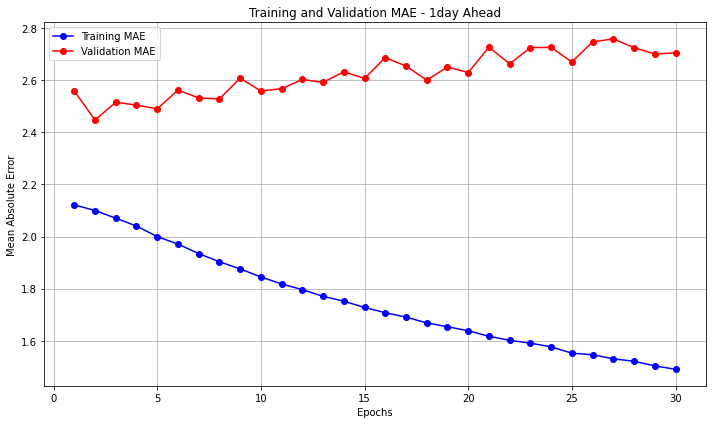

In [50]:
import matplotlib.pyplot as plt

mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 1day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

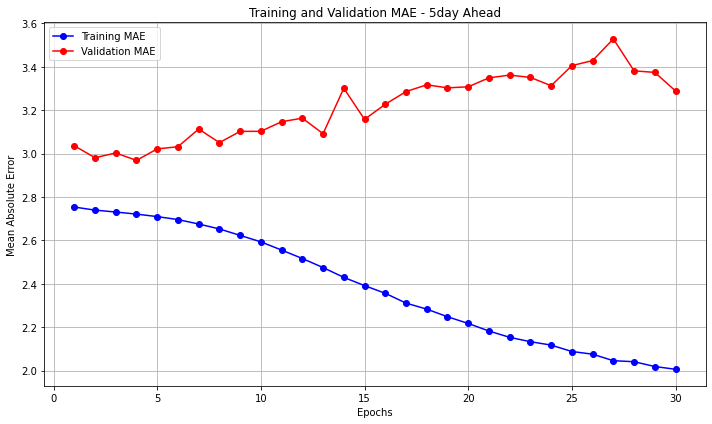

In [37]:
import matplotlib.pyplot as plt

mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 5day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

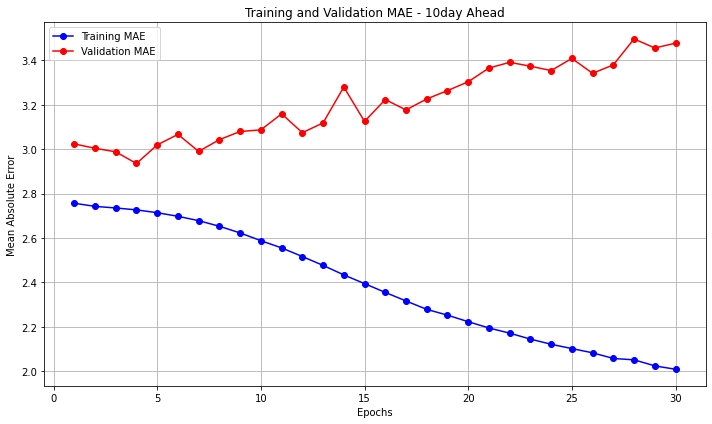

In [61]:
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 10day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

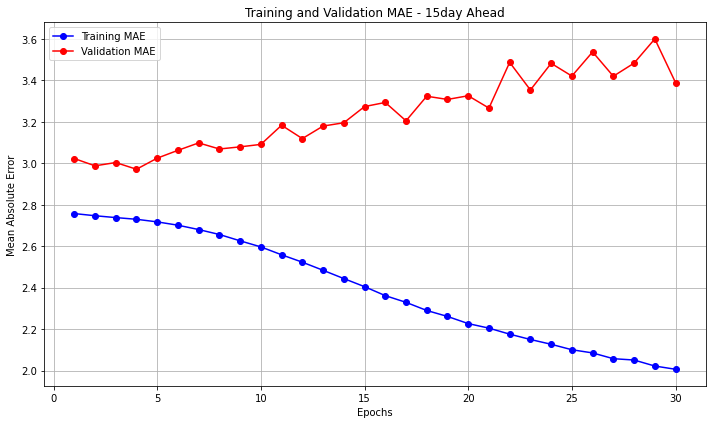

In [68]:
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 15day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

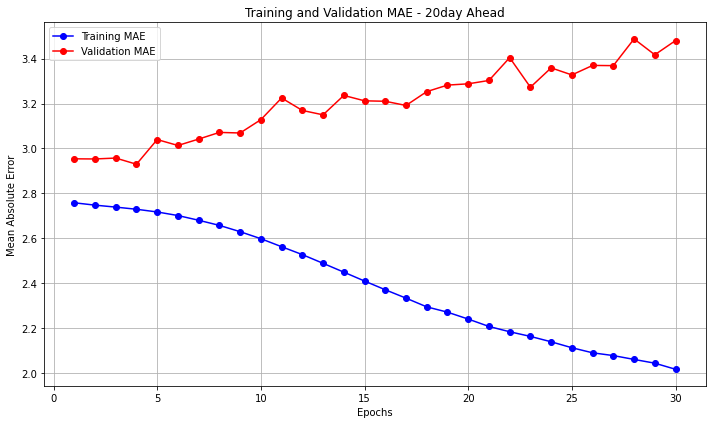

In [75]:
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 20day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

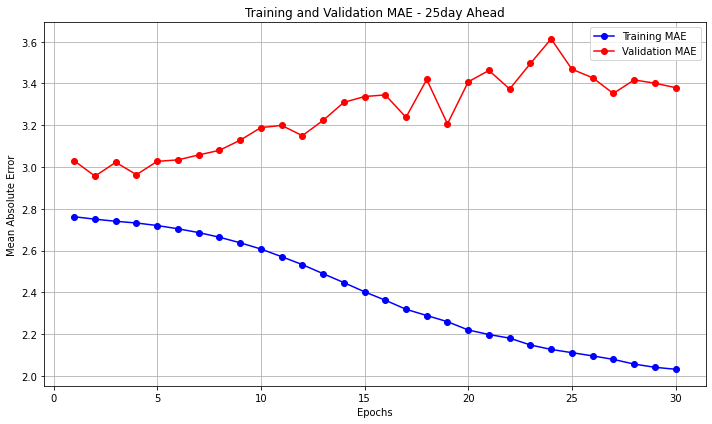

In [82]:
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 25day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

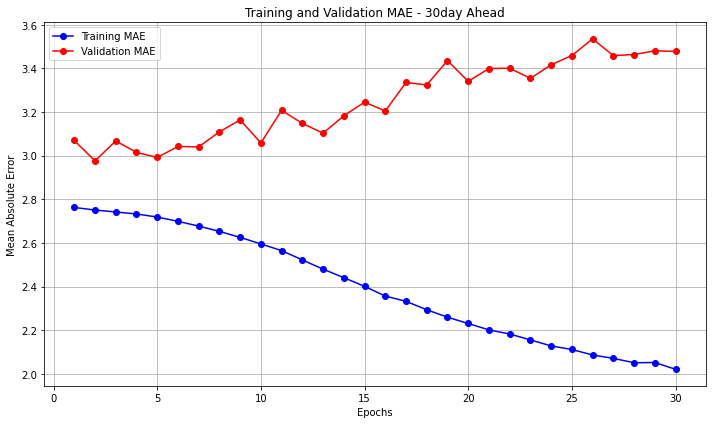

In [89]:
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(mae) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, mae, 'bo-', label='Training MAE')      # 'bo-' is blue circle line
plt.plot(epochs, val_mae, 'ro-', label='Validation MAE') # 'ro-' is red circle line
plt.title('Training and Validation MAE - 30day Ahead')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [90]:
best_model = tf.keras.models.load_model('best_model_30day.h5', compile=False)
best_model.compile(optimizer='adam', loss=Huber(delta=5.0), metrics=['mae'])

In [38]:
best_model = tf.keras.models.load_model('best_model_5day.h5', compile=False)
best_model.compile(optimizer='adam', loss=Huber(delta=5.0), metrics=['mae'])

In [91]:
y_pred = best_model.predict([X_num_val, X_cat_seq_val, X_cat_static_val])

y_pred = y_pred.flatten()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)

print(f"Validation MAE: {mae:.4f}")
print(f"Validation MSE: {mse:.4f}")
print(f"Validation RMSE: {np.sqrt(mse):.4f}")

729/729 [==============================] - 2s 3ms/step
Validation MAE: 2.9760
Validation MSE: 93.0905
Validation RMSE: 9.6483


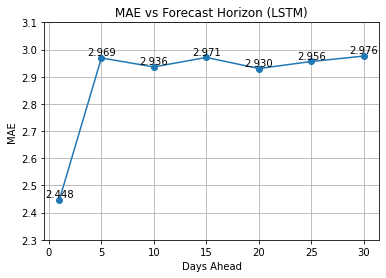

In [92]:
# Trend Over forecast horizon

# list of MAE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mae_per_horizon = [2.448, 2.969, 2.936, 2.971, 2.930, 2.956, 2.976]

plt.plot(horizons, mae_per_horizon, marker='o')
plt.title("MAE vs Forecast Horizon (LSTM)")
plt.xlabel("Days Ahead")
plt.ylabel("MAE")
plt.ylim(2.3, 3.1)
plt.grid(True)
for x, y in zip(horizons, mae_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


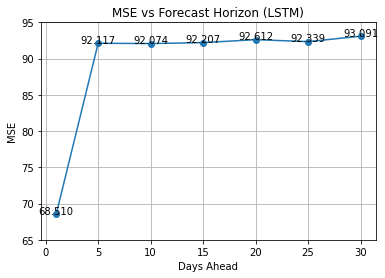

In [93]:
# Trend Over forecast horizon

# list of MSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mse_per_horizon = [68.510, 92.117, 92.074, 92.207, 92.612, 92.339, 93.091]

plt.plot(horizons, mse_per_horizon, marker='o')
plt.title("MSE vs Forecast Horizon (LSTM)")
plt.xlabel("Days Ahead")
plt.ylabel("MSE")
plt.ylim(65, 95)
plt.grid(True)
for x, y in zip(horizons, mse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


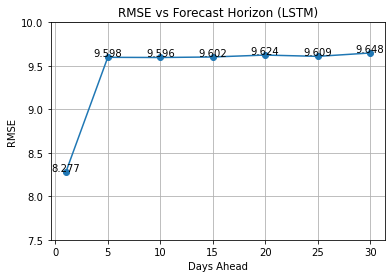

In [94]:
# Trend Over forecast horizon

# list of RMSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
rmse_per_horizon = [8.277, 9.598, 9.596, 9.602, 9.624, 9.609, 9.648]

plt.plot(horizons, rmse_per_horizon, marker='o')
plt.title("RMSE vs Forecast Horizon (LSTM)")
plt.xlabel("Days Ahead")
plt.ylabel("RMSE")
plt.ylim(7.5, 10)
plt.grid(True)
for x, y in zip(horizons, rmse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


In [9]:
def create_lstm_sequences_split(
    df,
    cat_static=['Location', 'Month'],
    cat_sequence=['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'],
    target_col='Rainfall',
    time_col='Date',
    location_col='Location',
    n_steps=7,
    forecast_horizon=1  # Change this to 5, 10, etc.
):
    X_num, X_cat_static, X_cat_seq, y = [], [], [], []

    for loc, group in df.groupby(location_col):
        group = group.sort_values(time_col).reset_index(drop=True)

        for i in range(len(group) - n_steps - forecast_horizon + 1):
            window = group.iloc[i:i + n_steps]

            # Target is Rainfall at t + forecast_horizon
            y.append(group.iloc[i + n_steps + forecast_horizon - 1][target_col])

            static_cat = window.iloc[0][cat_static].values
            X_cat_static.append(static_cat)

            seq_cat = window[cat_sequence].values
            X_cat_seq.append(seq_cat)

            drop_cols = [time_col, target_col] + cat_static + cat_sequence
            seq_num = window.drop(columns=drop_cols).values
            X_num.append(seq_num)

    return (
        np.array(X_num),
        np.array(X_cat_static),
        np.array(X_cat_seq),
        np.array(y)
    )

X_num, X_cat_static, X_cat_seq, y = create_lstm_sequences_split(df)

In [11]:
import tensorflow as tf

AttributeError: module 'numpy' has no attribute 'typeDict'

In [10]:
best_model = tf.keras.models.load_model('best_model_1day.h5', compile=False)
best_model.compile(optimizer='adam', loss=Huber(delta=5.0), metrics=['mae'])

NameError: name 'tf' is not defined

In [ ]:
y_pred = best_model.predict([X_num_val, X_cat_seq_val, X_cat_static_val])

y_pred = y_pred.flatten()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.plot([0, y_val.max()], [0, y_val.max()], '--r')
plt.xlabel("Actual Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("Actual vs Predicted Rainfall, LR 1-day Ahead")
plt.grid(True)
plt.show()